# Explainability SHAP - SARFIRE-GIF

## Objetivo del Notebook

Este notebook analiza la **explicabilidad** del modelo XGBoost optimizado usando SHAP (SHapley Additive exPlanations) para entender **por qué** el modelo predice GIF o No-GIF.

**Contexto:**
- **Modelo:** XGBoost optimizado (Recall 70.8%)
- **Objetivo:** Explicar las predicciones del modelo
- **Técnica:** SHAP
- **Dataset test:** 15,742 registros (2016-2020)

**Visualizaciones generadas:**
1. **Summary Plot (Beeswarm):** Importancia global de features + dirección del efecto
2. **Bar Plot:** Importancia promedio absoluta
3. **Dependence Plots:** Relación feature → predicción (Top 3 features)
4. **Waterfall Plots:** Explicación de casos individuales (TP, FN, FP)
5. **Interaction Analysis:** Interacciones entre features (opcional)

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
from datetime import datetime
import warnings

# Config visualización
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Inicializar SHAP JS para visualizaciones interactivas (opcional, puede no existir en versiones recientes)
try:
    shap.initjs()
except AttributeError:
    pass

print(f"Inicio análisis SHAP: {datetime.now()}")

Inicio análisis SHAP: 2026-03-08 00:16:05.447686


## 2. Cargar modelo y datos

In [2]:
# Cargar modelo optimizado
model = joblib.load('../models/xgb_optimized.joblib')

# Cargar datos procesados
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').values.ravel()
y_test = pd.read_csv('../data/processed/y_test.csv').values.ravel()

# Cargar preprocessor
preprocessor = joblib.load('../models/preprocessor_baseline.joblib')

# Transformar
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Feature names después del preprocessing
feature_names = preprocessor.get_feature_names_out()

print(f"Datos cargados:")
print(f"  Train: {X_train_processed.shape}")
print(f"  Test: {X_test_processed.shape}")
print(f"  Features: {len(feature_names)}")

Datos cargados:
  Train: (275302, 36)
  Test: (15742, 36)
  Features: 36


## 3. Calcular SHAP values

In [3]:
# IMPORTANTE: Para XGBoost usar TreeExplainer (mucho más rápido)
print("\n🔍 Calculando SHAP values con TreeExplainer...")
print("Esto puede tomar 2-5 minutos...")

explainer = shap.TreeExplainer(model)

# Calcular SHAP values para el test set
# Usar muestra si el test es muy grande para acelerar visualizaciones
sample_size = min(1000, len(X_test_processed))
X_test_sample = X_test_processed[:sample_size]
y_test_sample = y_test[:sample_size]

shap_values = explainer.shap_values(X_test_sample)

print(f"✅ SHAP values calculados")
print(f"  Shape: {shap_values.shape}")
print(f"  Muestra analizada: {sample_size} registros de test")


🔍 Calculando SHAP values con TreeExplainer...
Esto puede tomar 2-5 minutos...
✅ SHAP values calculados
  Shape: (1000, 36)
  Muestra analizada: 1000 registros de test


## 4. Summary Plot (Beeswarm) - GLOBAL


=== SUMMARY PLOT (Global Feature Importance) ===


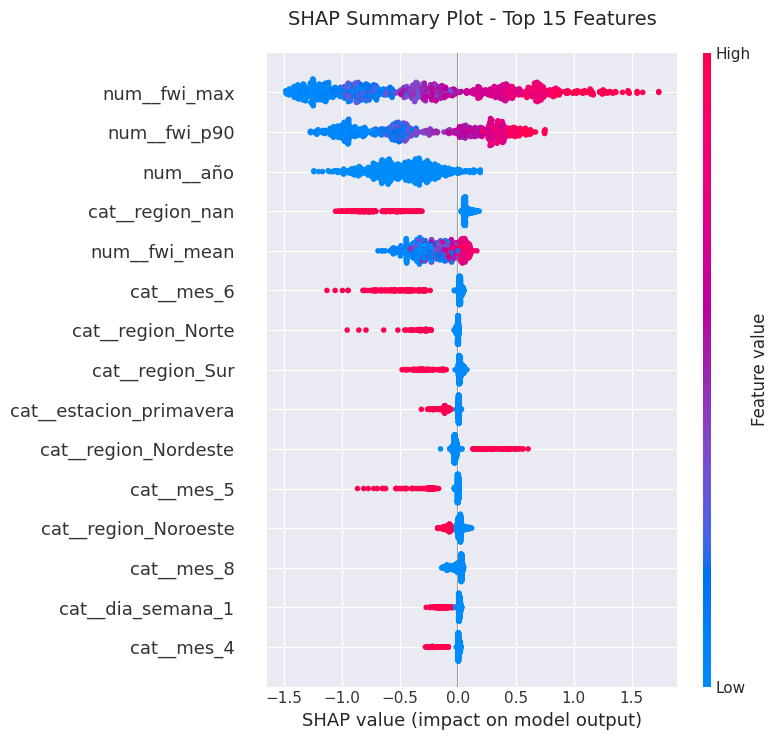


INTERPRETACIÓN:
- Eje X: SHAP value (impacto en la predicción)
- Cada punto: un registro
- Color: valor del feature (rojo=alto, azul=bajo)
- Posición vertical: importancia del feature
- Dispersión horizontal: variabilidad del impacto



In [4]:
# Summary plot: muestra importancia + dirección del efecto
print("\n=== SUMMARY PLOT (Global Feature Importance) ===")

plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values, 
    X_test_sample,
    feature_names=feature_names,
    max_display=15,
    show=False
)
plt.title('SHAP Summary Plot - Top 15 Features', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

print("""
INTERPRETACIÓN:
- Eje X: SHAP value (impacto en la predicción)
- Cada punto: un registro
- Color: valor del feature (rojo=alto, azul=bajo)
- Posición vertical: importancia del feature
- Dispersión horizontal: variabilidad del impacto
""")

## 5. Bar Plot - Importancia promedio


=== BAR PLOT (Mean Absolute SHAP Values) ===


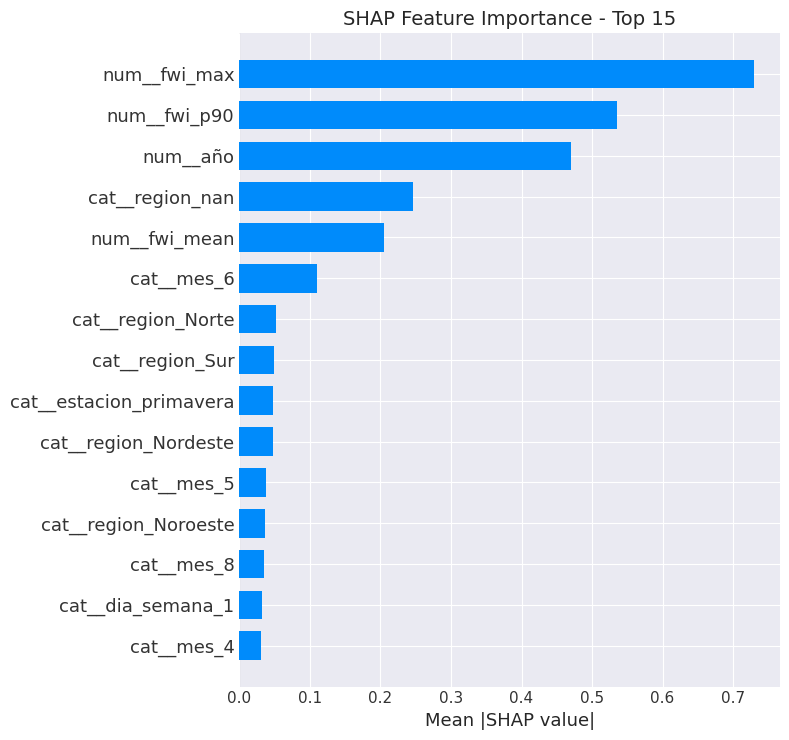

In [5]:
# Bar plot: importancia promedio absoluta
print("\n=== BAR PLOT (Mean Absolute SHAP Values) ===")

plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values,
    X_test_sample,
    feature_names=feature_names,
    plot_type="bar",
    max_display=15,
    show=False
)
plt.title('SHAP Feature Importance - Top 15', fontsize=14)
plt.xlabel('Mean |SHAP value|')
plt.tight_layout()
plt.show()

## 6. Dependence Plots - Top 3 features


=== DEPENDENCE PLOTS - Top 3 Features ===
Features analizados: ['num__fwi_max', 'num__fwi_p90', 'num__año']


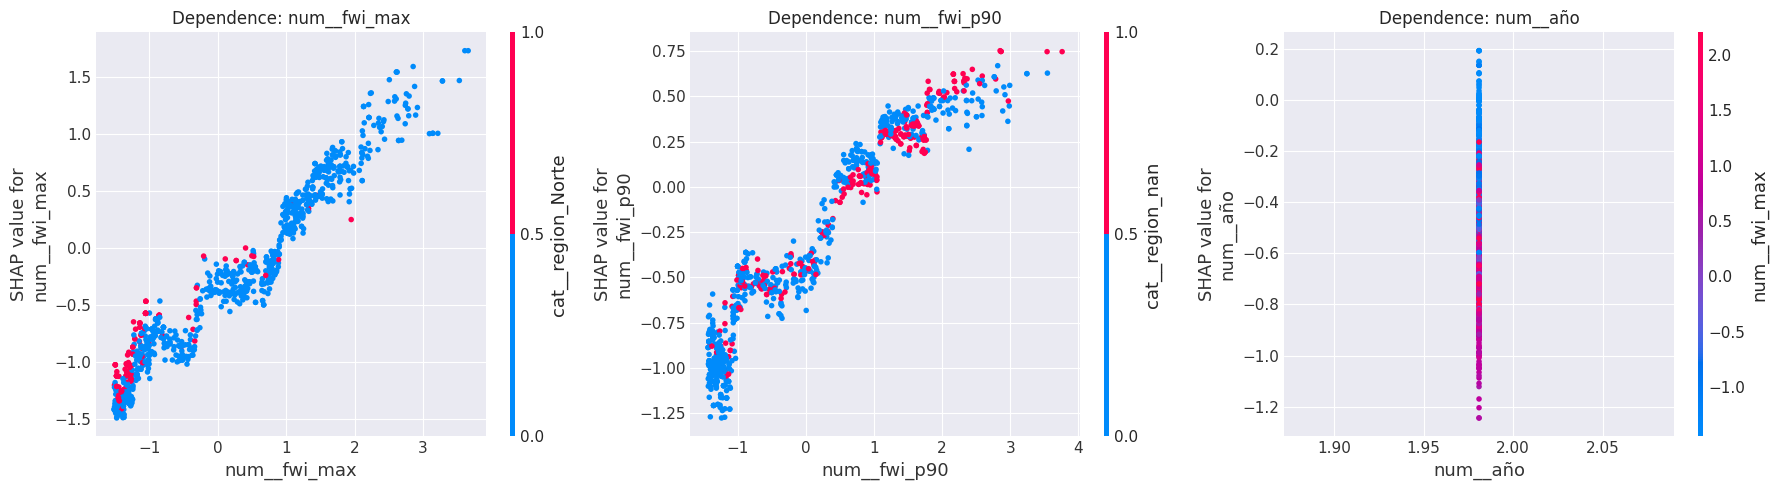


INTERPRETACIÓN:
- Eje X: Valor del feature
- Eje Y: SHAP value (impacto en predicción)
- Muestra relación no-lineal entre feature y predicción
- Color: interacción con otro feature



In [6]:
# Calcular importancia promedio para identificar top features
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top_indices = np.argsort(mean_abs_shap)[::-1][:3]
top_features = [feature_names[i] for i in top_indices]

print(f"\n=== DEPENDENCE PLOTS - Top 3 Features ===")
print(f"Features analizados: {top_features}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (feature_idx, feature_name) in enumerate(zip(top_indices, top_features)):
    plt.sca(axes[idx])
    shap.dependence_plot(
        feature_idx,
        shap_values,
        X_test_sample,
        feature_names=feature_names,
        show=False,
        ax=axes[idx]
    )
    axes[idx].set_title(f'Dependence: {feature_name}', fontsize=12)

plt.tight_layout()
plt.show()

print("""
INTERPRETACIÓN:
- Eje X: Valor del feature
- Eje Y: SHAP value (impacto en predicción)
- Muestra relación no-lineal entre feature y predicción
- Color: interacción con otro feature
""")

## 7. Waterfall Plots - Casos individuales


=== WATERFALL PLOTS - Explicación de casos individuales ===

--- CASO 1: True Positive (GIF detectado correctamente) ---
Índice: 572
Real: GIF | Predicho: GIF | Probabilidad: 79.55%


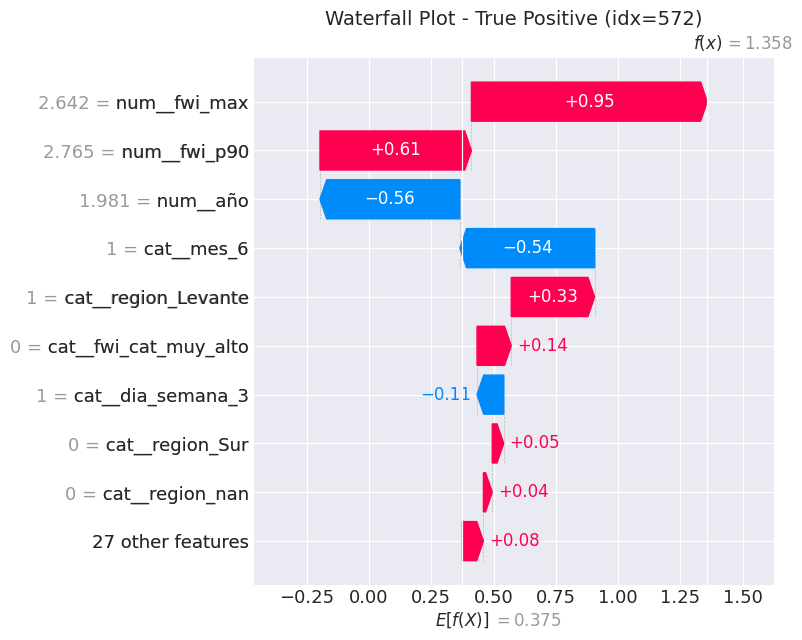


--- CASO 2: False Negative (GIF NO detectado) ---
Índice: 673
Real: GIF | Predicho: No-GIF | Probabilidad: 26.75%


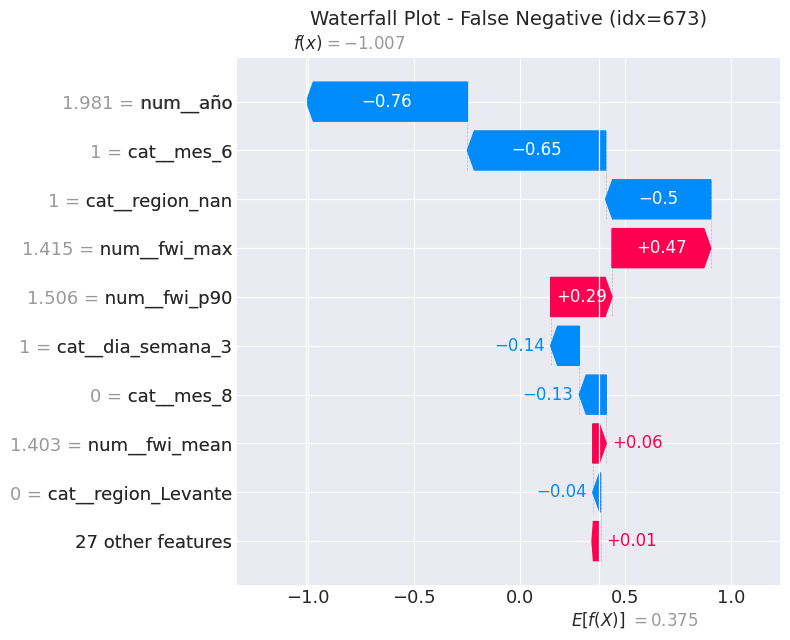


--- CASO 3: False Positive (Falsa alarma) ---
Índice: 796
Real: No-GIF | Predicho: GIF | Probabilidad: 92.67%


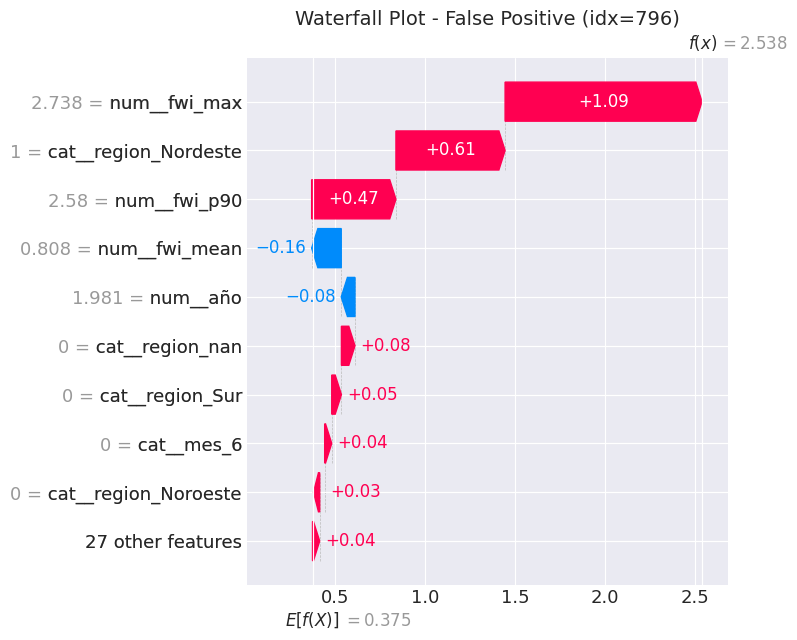


INTERPRETACIÓN WATERFALL:
- Base value (E[f(X)]): predicción promedio del modelo
- Cada barra: contribución de un feature
- Rojo: empuja hacia GIF (positivo)
- Azul: empuja hacia No-GIF (negativo)
- f(x): predicción final



In [7]:
print("\n=== WATERFALL PLOTS - Explicación de casos individuales ===")

# Obtener predicciones
y_pred = model.predict(X_test_processed)
y_proba = model.predict_proba(X_test_processed)[:, 1]

# Seleccionar 3 casos interesantes:
# 1. True Positive (GIF correctamente detectado, alta probabilidad)
# 2. False Negative (GIF no detectado)
# 3. False Positive (No-GIF predicho como GIF)

# Caso 1: TP con probabilidad alta
tp_mask = (y_test_sample == 1) & (model.predict(X_test_sample) == 1)
tp_probas = y_proba[:sample_size][tp_mask]
if len(tp_probas) > 0:
    tp_idx = np.where(tp_mask)[0][np.argmax(tp_probas)]
    
    print(f"\n--- CASO 1: True Positive (GIF detectado correctamente) ---")
    print(f"Índice: {tp_idx}")
    print(f"Real: GIF | Predicho: GIF | Probabilidad: {y_proba[tp_idx]:.2%}")
    
    plt.figure(figsize=(12, 6))
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[tp_idx],
            base_values=explainer.expected_value,
            data=X_test_sample[tp_idx],
            feature_names=feature_names
        ),
        max_display=10,
        show=False
    )
    plt.title(f'Waterfall Plot - True Positive (idx={tp_idx})', fontsize=14)
    plt.tight_layout()
    plt.show()

# Caso 2: FN (GIF no detectado)
fn_mask = (y_test_sample == 1) & (model.predict(X_test_sample) == 0)
if fn_mask.sum() > 0:
    fn_idx = np.where(fn_mask)[0][0]
    
    print(f"\n--- CASO 2: False Negative (GIF NO detectado) ---")
    print(f"Índice: {fn_idx}")
    print(f"Real: GIF | Predicho: No-GIF | Probabilidad: {y_proba[fn_idx]:.2%}")
    
    plt.figure(figsize=(12, 6))
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[fn_idx],
            base_values=explainer.expected_value,
            data=X_test_sample[fn_idx],
            feature_names=feature_names
        ),
        max_display=10,
        show=False
    )
    plt.title(f'Waterfall Plot - False Negative (idx={fn_idx})', fontsize=14)
    plt.tight_layout()
    plt.show()

# Caso 3: FP con alta probabilidad
fp_mask = (y_test_sample == 0) & (model.predict(X_test_sample) == 1)
fp_probas = y_proba[:sample_size][fp_mask]
if len(fp_probas) > 0:
    fp_idx = np.where(fp_mask)[0][np.argmax(fp_probas)]
    
    print(f"\n--- CASO 3: False Positive (Falsa alarma) ---")
    print(f"Índice: {fp_idx}")
    print(f"Real: No-GIF | Predicho: GIF | Probabilidad: {y_proba[fp_idx]:.2%}")
    
    plt.figure(figsize=(12, 6))
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[fp_idx],
            base_values=explainer.expected_value,
            data=X_test_sample[fp_idx],
            feature_names=feature_names
        ),
        max_display=10,
        show=False
    )
    plt.title(f'Waterfall Plot - False Positive (idx={fp_idx})', fontsize=14)
    plt.tight_layout()
    plt.show()

print("""
INTERPRETACIÓN WATERFALL:
- Base value (E[f(X)]): predicción promedio del modelo
- Cada barra: contribución de un feature
- Rojo: empuja hacia GIF (positivo)
- Azul: empuja hacia No-GIF (negativo)
- f(x): predicción final
""")

## 8. Análisis de interacciones (opcional)


=== INTERACTION ANALYSIS ===
Analizando interacciones de: num__fwi_max
Muestra para interacciones: 500


<Figure size 1200x800 with 0 Axes>

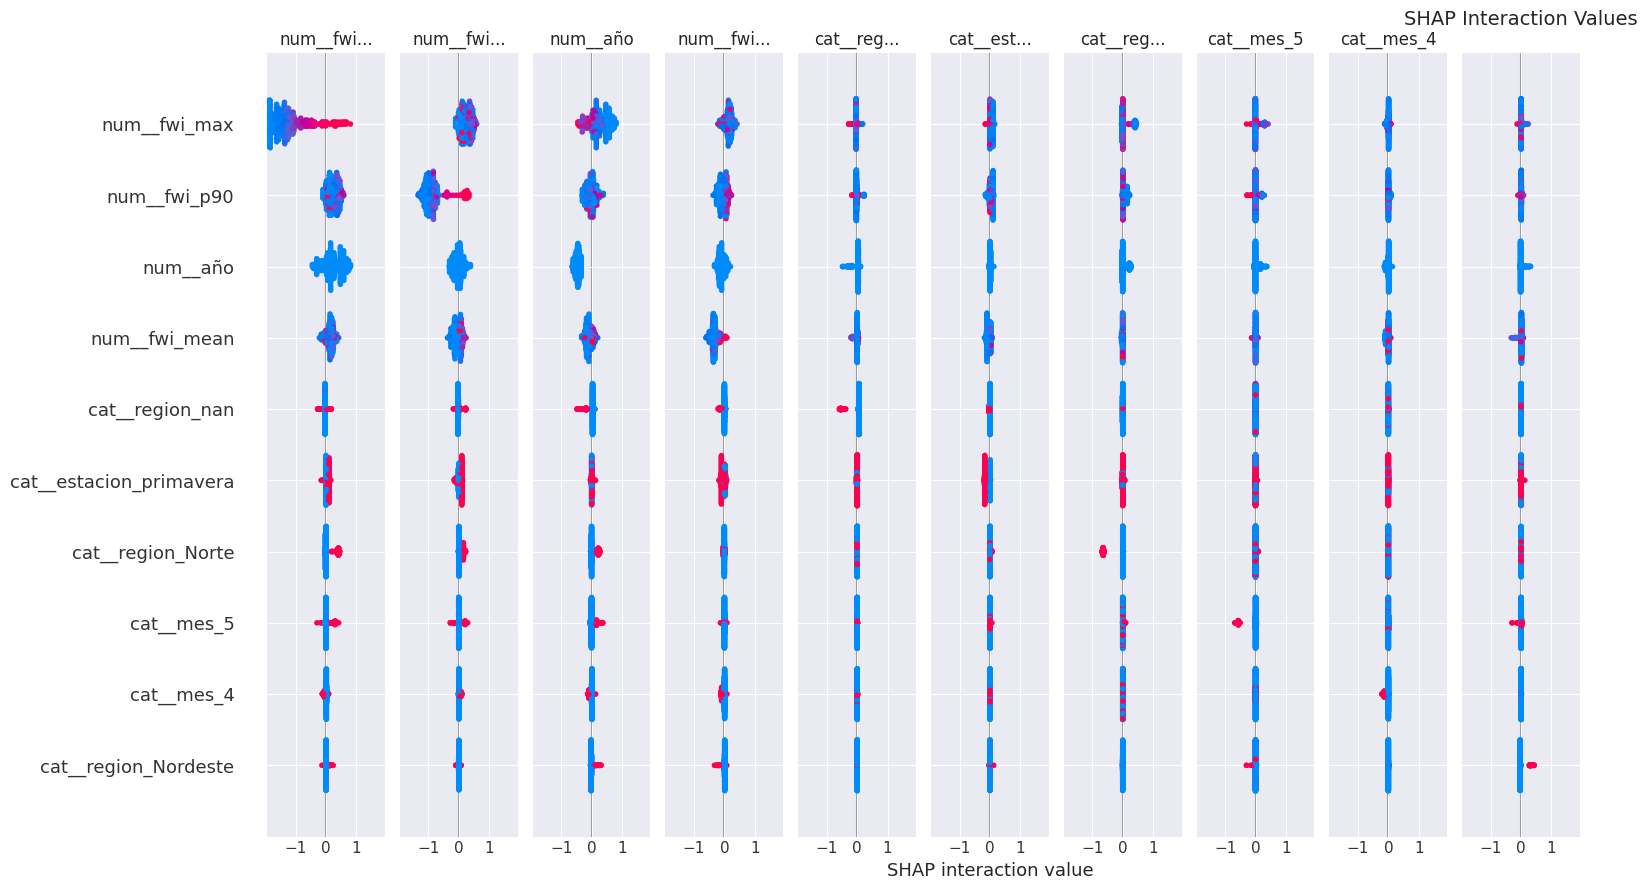

In [8]:
# Interaction plot para el feature más importante
print("\n=== INTERACTION ANALYSIS ===")

top_feature_idx = top_indices[0]
top_feature_name = feature_names[top_feature_idx]

print(f"Analizando interacciones de: {top_feature_name}")

# Calcular SHAP interaction values (esto puede tardar)
# Usar muestra pequeña para acelerar
interaction_sample_size = min(500, len(X_test_sample))
print(f"Muestra para interacciones: {interaction_sample_size}")

shap_interaction_values = explainer.shap_interaction_values(
    X_test_processed[:interaction_sample_size]
)

# Interaction summary
plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_interaction_values,
    X_test_processed[:interaction_sample_size],
    feature_names=feature_names,
    max_display=10,
    show=False
)
plt.title('SHAP Interaction Values', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

## 9. Resumen e interpretación

In [9]:
print("\n" + "="*70)
print("RESUMEN - ANÁLISIS SHAP")
print("="*70)

# Top 5 features por SHAP
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top_5_indices = np.argsort(mean_abs_shap)[::-1][:5]

print("\n📊 TOP 5 FEATURES MÁS INFLUYENTES:")
for i, idx in enumerate(top_5_indices, 1):
    feature_name = feature_names[idx]
    importance = mean_abs_shap[idx]
    print(f"{i}. {feature_name}: {importance:.4f}")

# Insights clave (analizar visualmente de los plots)
print("\n💡 INSIGHTS CLAVE (a completar manualmente tras revisar plots):")
print("""
1. [Feature principal]: [Cómo afecta]
2. [Interacciones]: [Qué combinaciones son críticas]
3. [Casos FN]: [Por qué el modelo falla en estos casos]
4. [Recomendaciones]: [Posibles mejoras]
""")

print("\n" + "="*70)
print(f"Análisis SHAP completado: {datetime.now()}")
print("="*70)


RESUMEN - ANÁLISIS SHAP

📊 TOP 5 FEATURES MÁS INFLUYENTES:
1. num__fwi_max: 0.7299
2. num__fwi_p90: 0.5356
3. num__año: 0.4696
4. cat__region_nan: 0.2468
5. num__fwi_mean: 0.2047

💡 INSIGHTS CLAVE (a completar manualmente tras revisar plots):

1. [Feature principal]: [Cómo afecta]
2. [Interacciones]: [Qué combinaciones son críticas]
3. [Casos FN]: [Por qué el modelo falla en estos casos]
4. [Recomendaciones]: [Posibles mejoras]


Análisis SHAP completado: 2026-03-08 00:26:36.496445
